# UMAP
Vamos a utilizar el modelo UMAP para reducir la dimensionaldiad del mismo dataset sintetico generado en [tSNE](../t-SNE/) y luego compararlo con [CPA](../PCA/).

### SETUP
Instalamos e importamos librerias, generamos dataset.

In [ ]:
!pip install -q numpy==2.2.0
!pip install -q pandas==2.2.3
!pip install -q matplotlib==3.9.3
!pip install -q plotly==5.24.1
!pip install -q --upgrade scikit-learn umap-learn

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import umap.umap_ as UMAP 
from sklearn.decomposition import PCA

import plotly.express as px
from sklearn.datasets import make_blobs

# Generamos dataset 


# Centroides:
centers = [ [ 2, -6, -6],
            [-1,  9,  4],
            [-8,  7,  2],
            [ 4,  7,  9] ]

# Desviacion estandar:
cluster_std=[1,1,2,3.5]

# Creamos blobs, obtenemos labels y data
X, labels_ = make_blobs(n_samples=500, centers=centers, n_features=3, cluster_std=cluster_std, random_state=42)

En caso de querer visualizar los blobs ver [tSNE](../t-SNE/tSNE.ipynb)

### Preprocesamiento del Dataset
Estandaricemos nuestro dataset para poder utilizarlo en nuestro modelo


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Creacion del modelo
Ahora si podemos crear los modelos UMAP y PCA y comprarlos. 

In [9]:
# Creamos modelo UMAP
umap_model = UMAP.UMAP(n_components=2, random_state=42, min_dist=0.5, spread=1,n_jobs=1)

# Utilizamos modelo para reducir dimensionalidad
X_umap = umap_model.fit_transform(X_scaled)

# Creamos modelo PCA
PCA_model = PCA(n_components = 2)

# Reducimos dimensionalidad
X_pca = PCA_model.fit_transform(X_scaled)

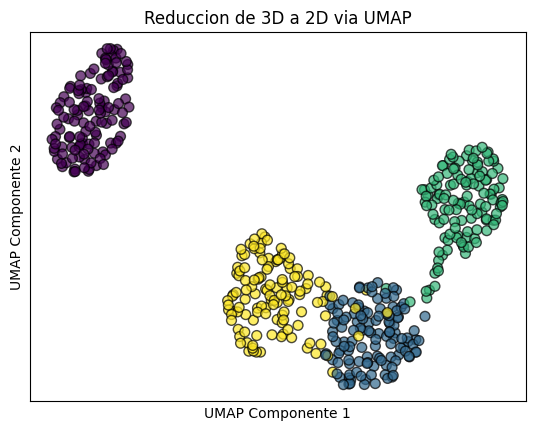

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')

ax.set_title("Reduccion de 3D a 2D via UMAP")
ax.set_xlabel("UMAP Componente 1", )
ax.set_ylabel("UMAP Componente 2", )
ax.set_xticks([])
ax.set_yticks([])
plt.show()

Podemos observar que UMAP dentro de todo tuvo un buen rendimiento, la densidad es relativamente consistente respecto a la original, algunos puntos estan superpuestos entre clusters pero esto no es necesariamente malo.

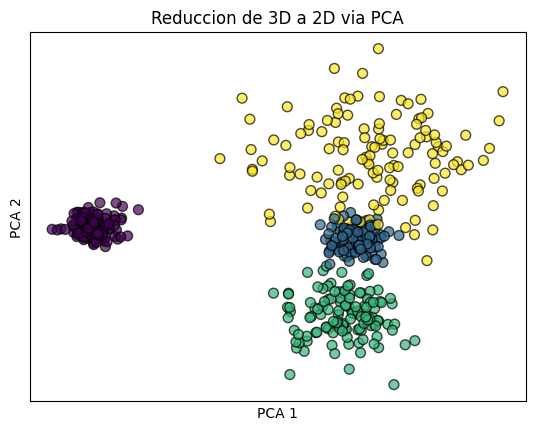

In [21]:
fig = plt.figure()

ax2 = fig.add_subplot(111)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax2.set_title("Reduccion de 3D a 2D via PCA")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_xticks([])
ax2.set_yticks([])
plt.show()

Como mencionamos antes, algunas densidades no son persistentes respecto a las originales, la superposición existe (pero igual que en los otros modelos), sin embargo los 3 fueron consistentes en las distancias. <br>
Lejos de tener un resultado evidentemente superior en los algoritmos mas avanzados como lo son UMAP y tSNE podemos observar que PCA trabajó de una forma sorprendentemente buena teniendo en cuenta el *tradeoff* de simplicidad